# Personalised movie recommendation system using collabrative filtering

# Project Objective


The objective of this project is to design and build a personalized movie recommendation system using collaborative filtering. Users of streaming platforms face a very large catalogue and often struggle to find movies that match their taste, which reduces engagement and satisfaction. Using historical user ratings, the system will identify users with similar preferences and movies with similar rating patterns, predict ratings for unseen movies, and recommend the top N most relevant titles to each user. The models will be evaluated using RMSE and Precision@K, and limitations such as data sparsity and the cold-start problem will be addressed. The outcome is a recommendation engine that helps users discover relevant content faster and helps the business improve engagement and retention.

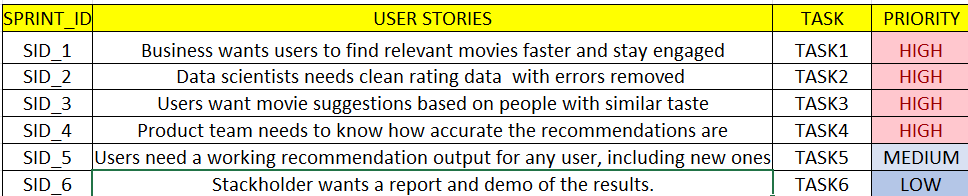

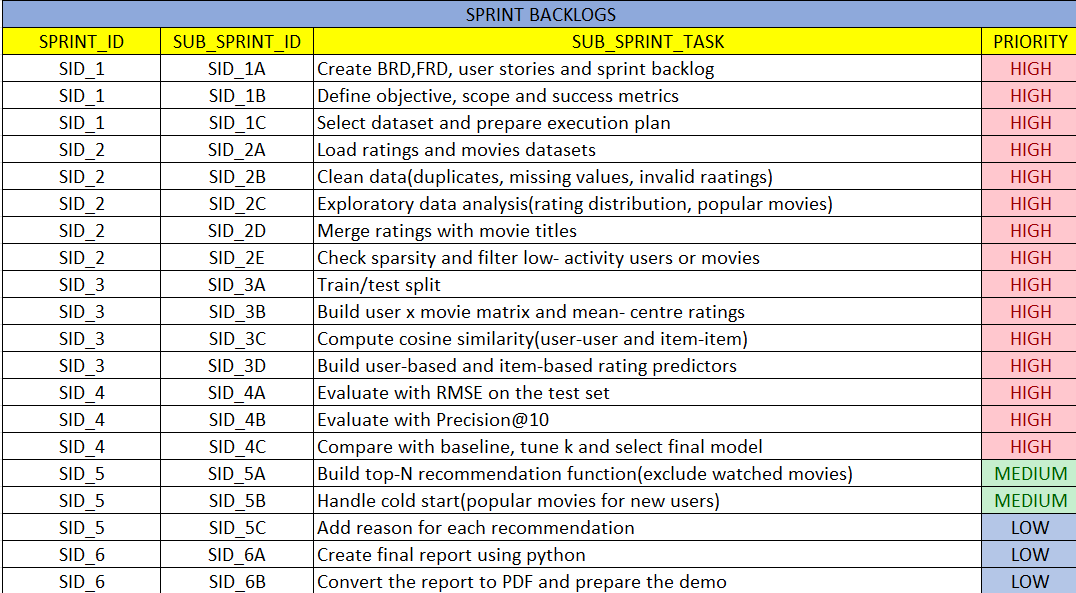

# Step 1: Load important modules


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("All Modules Loaded Successfully!!")

All Modules Loaded Successfully!!


# Step 2: Load Dataset


In [10]:
movies_df = pd.read_csv("https://github.com/Sravyatogarla/Movie-recommendation-system/raw/refs/heads/main/movies.csv")
ratings_df  = pd.read_csv("https://github.com/Sravyatogarla/Movie-recommendation-system/raw/refs/heads/main/ratings.csv")
print("Done")

Done


In [14]:
print(movies_df.columns.tolist())
print(ratings_df.columns.tolist())
print(movies_df.shape,ratings_df.shape)

['movieId', 'title', 'genres']
['userId', 'movieId', 'rating', 'timestamp']
(10329, 3) (105339, 4)


# Step 3: Look at data and clean it

In [12]:
# Step 3.1: Look at the data
all_dfs=[movies_df,
         ratings_df]

for i in all_dfs:
  print('='*50)
  display(i.sample(2))


,movieId,title,genres
343,384,Bad Company (1995),Action|Crime|Drama
6264,26937,Jack Frost (1997),Comedy|Fantasy|Horror


,userId,movieId,rating,timestamp
68590,469,95,3.0,865436260
36528,244,862,4.0,953168807


In [15]:
# Step 3.2: Check the shape of tables
print("movies_df :", movies_df.shape)
print("ratings_df:", ratings_df.shape)

movies_df : (10329, 3)
ratings_df: (105339, 4)


In [16]:
# Step 3.3: Show column info
movies_df.info()
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10329 entries, 0 to 10328
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  10329 non-null  int64 
 1   title    10329 non-null  object
 2   genres   10329 non-null  object
dtypes: int64(1), object(2)
memory usage: 242.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105339 entries, 0 to 105338
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     105339 non-null  int64  
 1   movieId    105339 non-null  int64  
 2   rating     105339 non-null  float64
 3   timestamp  105339 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.2 MB


In [17]:
# Step 3.4: Check missing values
print(movies_df.isnull().sum())
print(ratings_df.isnull().sum())

movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [18]:
# Step 3.5: Check duplicates
print("Duplicate rows:", ratings_df.duplicated().sum())
print("Duplicate user-movie pairs:", ratings_df.duplicated(subset=['userId', 'movieId']).sum())

Duplicate rows: 0
Duplicate user-movie pairs: 0


In [19]:
# Step 3.6: Check rating values
print(ratings_df['rating'].describe())
print(sorted(ratings_df['rating'].unique()))

count    105339.000000
mean          3.516850
std           1.044872
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64
[np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


In [20]:
# Step 3.7: Merge datasets with movieId
merged_df = pd.merge(ratings_df, movies_df, on='movieId')
print(merged_df.shape)
merged_df.head()

(105339, 6)


,userId,movieId,rating,timestamp,title,genres
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [21]:
# Step 3.8: Dataset summary
print("Ratings:", len(merged_df))
print("Users  :", merged_df['userId'].nunique())
print("Movies :", merged_df['movieId'].nunique())
print("Average rating:", round(merged_df['rating'].mean(), 2))

Ratings: 105339
Users  : 668
Movies : 10325
Average rating: 3.52


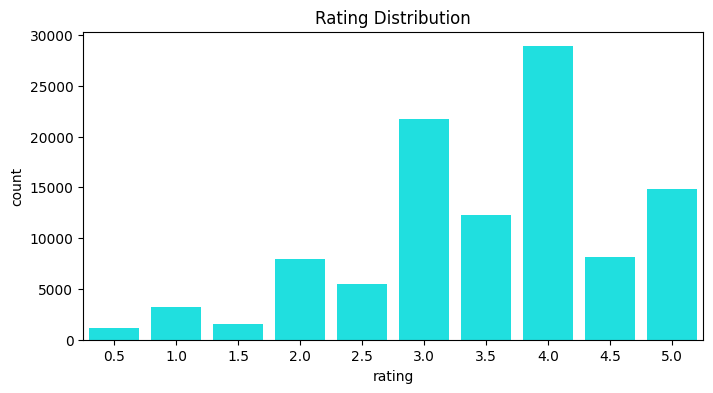

In [24]:
# Step 3.9: Rating distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=merged_df, color='aqua')
plt.title('Rating Distribution')
plt.show()

count     668.000000
mean      157.693114
std       319.712512
min        20.000000
25%        35.000000
50%        70.500000
75%       153.000000
max      5678.000000
Name: rating, dtype: float64


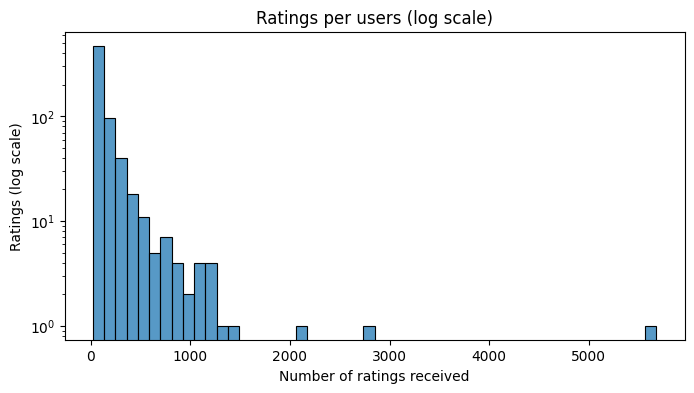

In [32]:
# Step 3.10: Ratings per user
ratings_per_user = merged_df.groupby('userId')['rating'].count()
print(ratings_per_user.describe())

plt.figure(figsize=(8, 4))
sns.histplot(ratings_per_user, bins=50)
plt.yscale('log')
plt.title('Ratings per users (log scale)')
plt.xlabel('Number of ratings received')
plt.ylabel('Ratings (log scale)')
plt.show()

count    10323.000000
mean        10.204301
std         22.834557
min          1.000000
25%          1.000000
50%          3.000000
75%          8.000000
max        325.000000
Name: rating, dtype: float64


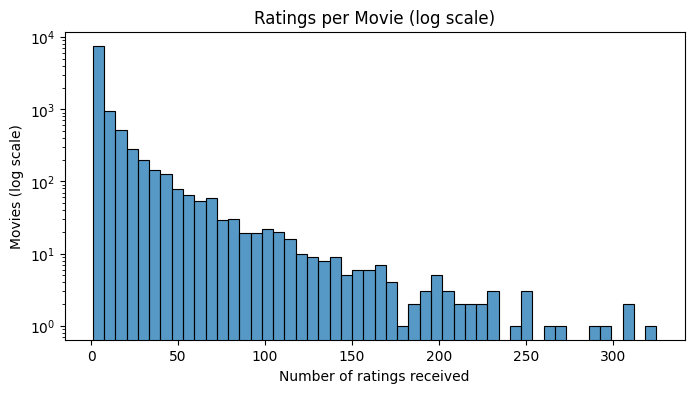

In [31]:
# Step 3.11: Ratings per movie
ratings_per_movie = merged_df.groupby('title')['rating'].count()
print(ratings_per_movie.describe())
plt.figure(figsize=(8, 4))
sns.histplot(ratings_per_movie, bins=50)
plt.yscale('log')
plt.title('Ratings per Movie (log scale)')
plt.xlabel('Number of ratings received')
plt.ylabel('Movies (log scale)')
plt.show()

In [33]:
# Step 3.12: Most rated movies
merged_df['title'].value_counts().head(10)

,count
title,
Pulp Fiction (1994),325
Forrest Gump (1994),311
"Shawshank Redemption, The (1994)",308
Jurassic Park (1993),294
"Silence of the Lambs, The (1991)",290
Star Wars: Episode IV - A New Hope (1977),273
"Matrix, The (1999)",261
Terminator 2: Judgment Day (1991),253
Schindler's List (1993),248


In [34]:
# Step 3.13: Highest rated movies (at least 50 ratings)
stats = merged_df.groupby('title')['rating'].agg(['mean', 'count'])
stats[stats['count'] >= 50].sort_values('mean', ascending=False).head(10)

,mean,count
title,,
"Shawshank Redemption, The (1994)",4.454545,308
Citizen Kane (1941),4.396104,77
"Godfather, The (1972)",4.392857,210
Princess Mononoke (Mononoke-hime) (1997),4.384615,52
Rear Window (1954),4.331081,74
"Usual Suspects, The (1995)",4.328947,228
Chinatown (1974),4.323529,68
Monty Python and the Holy Grail (1975),4.301948,154
Schindler's List (1993),4.296371,248


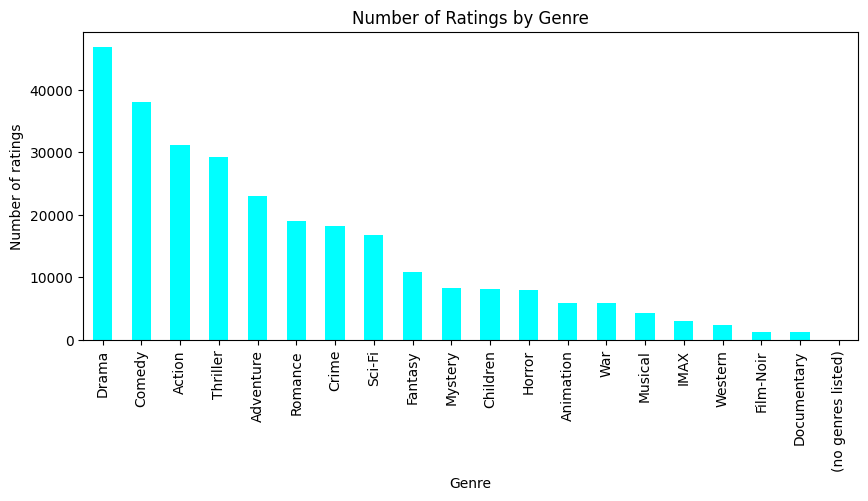

In [36]:
# Step 3.14: Number of ratings by genre
genres = merged_df['genres'].str.split('|').explode()
plt.figure(figsize=(10, 4))
genres.value_counts().plot(kind='bar', color='aqua')
plt.title('Number of Ratings by Genre')
plt.xlabel('Genre')
plt.ylabel('Number of ratings')
plt.show()

In [37]:
# Step 3.15: Sparsity check
num_users = merged_df['userId'].nunique()
num_movies = merged_df['movieId'].nunique()
num_ratings = len(merged_df)

total_possible = num_users * num_movies
sparsity = 1 - (num_ratings / total_possible)

print("Number of users:", num_users)
print("Number of movies:", num_movies)
print("Number of ratings:", num_ratings)
print("Total possible ratings:", total_possible)
print("Sparsity:", round(sparsity * 100, 2), "%")

Number of users: 668
Number of movies: 10325
Number of ratings: 105339
Total possible ratings: 6897100
Sparsity: 98.47 %


In [38]:
# Step 3.16a: Effect of different movie thresholds
ratings_per_movie = merged_df.groupby('movieId')['rating'].count()
for t in [1, 3, 5, 10, 20]:
    keep = ratings_per_movie[ratings_per_movie >= t]
    print(f"min {t:>2} ratings -> {len(keep):>5} movies kept "
          f"({len(keep)/len(ratings_per_movie):.0%}), "
          f"{keep.sum():>6} ratings kept ({keep.sum()/ratings_per_movie.sum():.0%})")

min  1 ratings -> 10325 movies kept (100%), 105339 ratings kept (100%)
min  3 ratings ->  5232 movies kept (51%),  98791 ratings kept (94%)
min  5 ratings ->  3855 movies kept (37%),  94121 ratings kept (89%)
min 10 ratings ->  2315 movies kept (22%),  84049 ratings kept (80%)
min 20 ratings ->  1322 movies kept (13%),  70513 ratings kept (67%)


In [39]:
# Step 3.16b: Filter low-activity users and movies
min_user_ratings = 20
min_movie_ratings = 5

u = merged_df['userId'].value_counts()
m = merged_df['movieId'].value_counts()

filtered_df = merged_df[merged_df['userId'].isin(u[u >= min_user_ratings].index) &
                        merged_df['movieId'].isin(m[m >= min_movie_ratings].index)]

print("Before:", merged_df.shape, "| After:", filtered_df.shape)
print("Users :", merged_df['userId'].nunique(), "->", filtered_df['userId'].nunique())
print("Movies:", merged_df['movieId'].nunique(), "->", filtered_df['movieId'].nunique())

Before: (105339, 6) | After: (94121, 6)
Users : 668 -> 668
Movies: 10325 -> 3855


In [40]:
# Step 3.17: Sparsity after filtering
n_users = filtered_df['userId'].nunique()
n_movies = filtered_df['movieId'].nunique()
new_sparsity = 1 - len(filtered_df) / (n_users * n_movies)
print("Sparsity before:", round(sparsity * 100, 2), "%")
print("Sparsity after :", round(new_sparsity * 100, 2), "%")

Sparsity before: 98.47 %
Sparsity after : 96.35 %


# Step 4: Train/Test Split

In [41]:
# Step 4.1: Split ratings into train and test (80/20)
test_df = filtered_df.sample(frac=0.2, random_state=42)
train_df = filtered_df.drop(test_df.index)
print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (75297, 6)
Test : (18824, 6)


In [42]:
# Step 4.2: Check test users and movies appear in train
print("Test users not in train :", (~test_df['userId'].isin(train_df['userId'])).sum())
print("Test movies not in train:", (~test_df['movieId'].isin(train_df['movieId'])).sum())

Test users not in train : 0
Test movies not in train: 5


# Step 5: User × Movie matrix

In [43]:
# Step 5.1: Build matrix from TRAIN data only
user_item = train_df.pivot_table(index='userId', columns='movieId', values='rating')
print("Matrix shape:", user_item.shape)

Matrix shape: (668, 3854)


In [44]:
# Step 5.2: Mean-centre each user's ratings
user_mean = user_item.mean(axis=1)
centred = user_item.sub(user_mean, axis=0).fillna(0)
centred.iloc[:5, :5]

movieId,1,2,3,4,5
userId,,,,,
1,0.000000,0.0,0.000000,0.0,0.000000
2,1.227273,0.0,-1.772727,0.0,-0.772727
3,0.000000,0.0,0.000000,0.0,-0.803279
4,0.000000,0.0,0.000000,0.0,0.000000
5,0.933962,0.0,0.000000,0.0,0.000000


# Step 6: Cosine Similarity

In [45]:
# Step 6.1: User-user and item-item similarity
user_sim = pd.DataFrame(cosine_similarity(centred),
                        index=user_item.index, columns=user_item.index)
item_sim = pd.DataFrame(cosine_similarity(centred.T),
                        index=user_item.columns, columns=user_item.columns)
print("User similarity:", user_sim.shape)
print("Item similarity:", item_sim.shape)

User similarity: (668, 668)
Item similarity: (3854, 3854)


In [46]:
# Step 6.2: Most similar movies to one movie (sanity check)
movie_titles = movies_df.set_index('movieId')['title']
some_movie = 1
print("Movies most similar to:", movie_titles[some_movie])
print(item_sim[some_movie].drop(some_movie).nlargest(5).rename(index=movie_titles))

Movies most similar to: Toy Story (1995)
movieId
Toy Story 2 (1999)                             0.226878
Anna and the King (1999)                       0.221718
Wallace & Gromit: The Wrong Trousers (1993)    0.220923
Princess Bride, The (1987)                     0.212090
Up (2009)                                      0.212045
Name: 1, dtype: float64


# Step 7: Item- based and user- based predictor

In [48]:
# Step 7.1: Item-based predictor
def predict_item(user, movie, k=30):
    if user not in user_item.index or movie not in user_item.columns:
        return train_df['rating'].mean()
    rated = user_item.loc[user].dropna().index.drop(movie, errors='ignore')
    if len(rated) == 0:
        return user_mean[user]
    sims = item_sim.loc[movie, rated].nlargest(k)
    denom = sims.abs().sum()
    if denom == 0:
        return user_mean[user]
    pred = user_mean[user] + (sims * centred.loc[user, sims.index]).sum() / denom
    return float(np.clip(pred, 0.5, 5))

In [49]:
# Step 7.2: User-based predictor
def predict_user(user, movie, k=30):
    if user not in user_item.index or movie not in user_item.columns:
        return train_df['rating'].mean()
    raters = user_item[movie].dropna().index.drop(user, errors='ignore')
    if len(raters) == 0:
        return user_mean[user]
    sims = user_sim.loc[user, raters].nlargest(k)
    denom = sims.abs().sum()
    if denom == 0:
        return user_mean[user]
    pred = user_mean[user] + (sims * centred.loc[sims.index, movie]).sum() / denom
    return float(np.clip(pred, 0.5, 5))

In [50]:
# Step 7.3: Quick test on 5 test ratings
for r in test_df.head(5).itertuples():
    print(f"actual {r.rating} | item-based {predict_item(r.userId, r.movieId):.2f} "
          f"| user-based {predict_user(r.userId, r.movieId):.2f}")

actual 4.5 | item-based 4.22 | user-based 4.30
actual 4.5 | item-based 4.43 | user-based 4.47
actual 4.0 | item-based 3.56 | user-based 3.75
actual 4.0 | item-based 4.16 | user-based 3.36
actual 2.0 | item-based 2.56 | user-based 2.44


# Step 8: Evaluation

In [51]:
# Step 8.1: RMSE and MAE on test data (a sample of 3000 keeps it fast)
eval_df = test_df.sample(3000, random_state=42)
actual = eval_df['rating'].values

item_preds = np.array([predict_item(r.userId, r.movieId) for r in eval_df.itertuples()])
user_preds = np.array([predict_user(r.userId, r.movieId) for r in eval_df.itertuples()])

global_avg = np.full(len(actual), train_df['rating'].mean())
user_avg   = eval_df['userId'].map(user_mean).fillna(train_df['rating'].mean()).values

def rmse(p): return np.sqrt(np.mean((actual - p) ** 2))
def mae(p):  return np.mean(np.abs(actual - p))

results = pd.DataFrame({
    'Model': ['Global average (baseline)', 'User average (baseline)', 'Item-based CF', 'User-based CF'],
    'RMSE':  [rmse(global_avg), rmse(user_avg), rmse(item_preds), rmse(user_preds)],
    'MAE':   [mae(global_avg),  mae(user_avg),  mae(item_preds),  mae(user_preds)]
}).round(3)
results

,Model,RMSE,MAE
0,Global average (baseline),1.042,0.836
1,User average (baseline),0.948,0.734
2,Item-based CF,0.867,0.653
3,User-based CF,0.879,0.663


In [52]:
# Step 8.2: Fast scoring of all unseen movies for one user (item-based)
def recommend_scores(user):
    rated_mask = user_item.loc[user].notna()
    S = item_sim.loc[:, rated_mask].values
    r = centred.loc[user, rated_mask].values
    num = S @ r
    den = np.abs(S).sum(axis=1)
    sc = user_mean[user] + np.divide(num, den, out=np.zeros_like(num), where=den > 0)
    return pd.Series(sc, index=item_sim.index)[~rated_mask.values]

In [53]:
# Step 8.3: Precision@10 for the model vs a popularity baseline
pop = train_df['movieId'].value_counts()
model_hits, pop_hits = [], []

for u in test_df['userId'].unique()[:100]:
    liked = set(test_df[(test_df.userId == u) & (test_df.rating >= 4)]['movieId'])
    if not liked:
        continue
    top_model = set(recommend_scores(u).nlargest(10).index)
    seen = set(user_item.columns[user_item.loc[u].notna()])
    top_pop = set(pop[~pop.index.isin(seen)].head(10).index)
    model_hits.append(len(liked & top_model) / 10)
    pop_hits.append(len(liked & top_pop) / 10)

print("Precision@10 - item-based CF:", round(np.mean(model_hits), 3))
print("Precision@10 - popularity   :", round(np.mean(pop_hits), 3))
print("Users evaluated:", len(model_hits))

Precision@10 - item-based CF: 0.087
Precision@10 - popularity   : 0.244
Users evaluated: 98


In [55]:
# Step 8.4: Improved scoring (minimum ratings + damping)
movie_counts = user_item.notna().sum()
def recommend_scores_v2(user, min_ratings=20, shrink=10):
    rated_mask = user_item.loc[user].notna()
    S = item_sim.loc[:, rated_mask].values
    r = centred.loc[user, rated_mask].values
    num = S @ r
    den = np.abs(S).sum(axis=1)
    sc = user_mean[user] + num / (den + shrink)
    s = pd.Series(sc, index=item_sim.index)
    keep = (~rated_mask.values) & (movie_counts.values >= min_ratings)
    return s[keep]

In [56]:
# Step 8.5: Compare settings (Precision@10 on the same 100 users)
def precision10(scorer, n_users=100, **kw):
    hits = []
    for u in test_df['userId'].unique()[:n_users]:
        liked = set(test_df[(test_df.userId == u) & (test_df.rating >= 4)]['movieId'])
        if not liked:
            continue
        top = set(scorer(u, **kw).nlargest(10).index)
        hits.append(len(liked & top) / 10)
    return round(np.mean(hits), 3)

for mr in [0, 20, 50]:
    for sh in [0, 10, 30]:
        print(f"min_ratings={mr:>2}, shrink={sh:>2} -> Precision@10 =",
              precision10(recommend_scores_v2, min_ratings=mr, shrink=sh))
print("Popularity baseline:", round(np.mean(pop_hits), 3))

/tmp/ipykernel_719/3638222319.py:9: RuntimeWarning: invalid value encountered in divide
  sc = user_mean[user] + num / (den + shrink)


min_ratings= 0, shrink= 0 -> Precision@10 = 0.087
min_ratings= 0, shrink=10 -> Precision@10 = 0.142
min_ratings= 0, shrink=30 -> Precision@10 = 0.133
min_ratings=20, shrink= 0 -> Precision@10 = 0.164
min_ratings=20, shrink=10 -> Precision@10 = 0.197
min_ratings=20, shrink=30 -> Precision@10 = 0.197
min_ratings=50, shrink= 0 -> Precision@10 = 0.205
min_ratings=50, shrink=10 -> Precision@10 = 0.235
min_ratings=50, shrink=30 -> Precision@10 = 0.235
Popularity baseline: 0.244


In [57]:
# Step 8.6: Confirm on users not used for tuning
all_users = test_df['userId'].unique()
eval_users = all_users[100:400]            # different users from the first 100

def precision10_on(users, scorer=None, **kw):
    hits = []
    for u in users:
        liked = set(test_df[(test_df.userId == u) & (test_df.rating >= 4)]['movieId'])
        if not liked:
            continue
        if scorer is None:                                   # popularity baseline
            seen = set(user_item.columns[user_item.loc[u].notna()])
            top = set(pop[~pop.index.isin(seen)].head(10).index)
        else:
            top = set(scorer(u, **kw).nlargest(10).index)
        hits.append(len(liked & top) / 10)
    return round(np.mean(hits), 3), len(hits)

print("Popularity            :", precision10_on(eval_users))
print("CF original           :", precision10_on(eval_users, recommend_scores))
print("CF min=20, shrink=10  :", precision10_on(eval_users, recommend_scores_v2, min_ratings=20, shrink=10))
print("CF min=50, shrink=10  :", precision10_on(eval_users, recommend_scores_v2, min_ratings=50, shrink=10))

Popularity            : (np.float64(0.139), 297)
CF original           : (np.float64(0.024), 297)
CF min=20, shrink=10  : (np.float64(0.088), 297)
CF min=50, shrink=10  : (np.float64(0.11), 297)


In [58]:
# Step 8.7: Paired comparison on the same users
def hits_per_user(users, scorer, **kw):
    out = []
    for u in users:
        liked = set(test_df[(test_df.userId == u) & (test_df.rating >= 4)]['movieId'])
        if not liked:
            continue
        top = set(scorer(u, **kw).nlargest(10).index)
        out.append(len(liked & top) / 10)
    return np.array(out)

def pop_scorer(user):
    seen = user_item.loc[user].notna()
    return movie_counts[~seen.values].astype(float)

h_cf  = hits_per_user(eval_users, recommend_scores_v2, min_ratings=50, shrink=10)
h_pop = hits_per_user(eval_users, pop_scorer)
d = h_cf - h_pop
print("Users:", len(d))
print("Mean difference (CF - popularity):", round(d.mean(), 3))
print("Standard error:", round(d.std(ddof=1) / np.sqrt(len(d)), 3))

Users: 297
Mean difference (CF - popularity): -0.029
Standard error: 0.007


In [59]:
# Step 8.8: Hybrid score = blend of personalised score and popularity
def recommend_hybrid(user, alpha=0.5, min_ratings=20, shrink=10):
    s = recommend_scores_v2(user, min_ratings=min_ratings, shrink=shrink)
    p = np.log1p(movie_counts.reindex(s.index))
    z = lambda x: (x - x.mean()) / x.std()
    return alpha * z(s) + (1 - alpha) * z(p)     # alpha=1: pure CF, alpha=0: pure popularity

# tune alpha on the FIRST 100 users
tune_users = all_users[:100]
for a in [0, 0.3, 0.5, 0.7, 1]:
    print(f"alpha={a} ->", hits_per_user(tune_users, recommend_hybrid, alpha=a).mean().round(3))

alpha=0 -> 0.245
alpha=0.3 -> 0.273
alpha=0.5 -> 0.278
alpha=0.7 -> 0.284
alpha=1 -> 0.197


In [60]:
# Step 8.9: Pick best alpha on tuning users, test on evaluation users
alphas = [0, 0.3, 0.5, 0.6, 0.7, 0.8, 1]
tune_scores = {a: hits_per_user(tune_users, recommend_hybrid, alpha=a).mean() for a in alphas}
best_alpha = max(tune_scores, key=tune_scores.get)
print("Tuning scores:", {a: round(s, 3) for a, s in tune_scores.items()})
print("Best alpha:", best_alpha)

h_hyb = hits_per_user(eval_users, recommend_hybrid, alpha=best_alpha)
h_pop = hits_per_user(eval_users, pop_scorer)
h_cf  = hits_per_user(eval_users, recommend_scores_v2, min_ratings=50, shrink=10)

print("\nPrecision@10 on", len(h_hyb), "evaluation users")
print("Popularity :", round(h_pop.mean(), 3))
print("CF (min=50):", round(h_cf.mean(), 3))
print("Hybrid     :", round(h_hyb.mean(), 3))

d = h_hyb - h_pop
print("\nHybrid - popularity:", round(d.mean(), 3), "| standard error:", round(d.std(ddof=1)/np.sqrt(len(d)), 3))

Tuning scores: {0: np.float64(0.245), 0.3: np.float64(0.273), 0.5: np.float64(0.278), 0.6: np.float64(0.284), 0.7: np.float64(0.284), 0.8: np.float64(0.271), 1: np.float64(0.197)}
Best alpha: 0.6

Precision@10 on 297 evaluation users
Popularity : 0.139
CF (min=50): 0.11
Hybrid     : 0.146

Hybrid - popularity: 0.007 | standard error: 0.005


# Step 9: Tune k and choose the final model

In [61]:
# Step 9.1: Tune k on one slice of the test set
tune_df   = test_df.sample(1000, random_state=1)
report_df = test_df.drop(tune_df.index).sample(3000, random_state=42)

tune_actual = tune_df['rating'].values
rows = []
for k in [10, 20, 30, 50, 100]:
    p = np.array([predict_item(r.userId, r.movieId, k=k) for r in tune_df.itertuples()])
    rows.append((k, round(np.sqrt(np.mean((tune_actual - p) ** 2)), 3)))
k_table = pd.DataFrame(rows, columns=['k', 'RMSE (item-based)'])
k_table

,k,RMSE (item-based)
0,10,0.874
1,20,0.870
2,30,0.870
3,50,0.873
4,100,0.879


In [62]:
# Step 9.2: Best k, then final numbers on a different slice
best_k = int(k_table.loc[k_table['RMSE (item-based)'].idxmin(), 'k'])
print("Best k:", best_k)

actual = report_df['rating'].values
item_p = np.array([predict_item(r.userId, r.movieId, k=best_k) for r in report_df.itertuples()])
user_p = np.array([predict_user(r.userId, r.movieId, k=best_k) for r in report_df.itertuples()])
glob_p = np.full(len(actual), train_df['rating'].mean())
uavg_p = report_df['userId'].map(user_mean).fillna(train_df['rating'].mean()).values

rm  = lambda p: np.sqrt(np.mean((actual - p) ** 2))
mae = lambda p: np.mean(np.abs(actual - p))

final_results = pd.DataFrame({
    'Model': ['Global average', 'User average', f'Item-based CF (k={best_k})', f'User-based CF (k={best_k})'],
    'RMSE':  [rm(glob_p), rm(uavg_p), rm(item_p), rm(user_p)],
    'MAE':   [mae(glob_p), mae(uavg_p), mae(item_p), mae(user_p)]
}).round(3)
final_results

Best k: 20


,Model,RMSE,MAE
0,Global average,1.018,0.824
1,User average,0.912,0.708
2,Item-based CF (k=20),0.826,0.631
3,User-based CF (k=20),0.840,0.638


# Step 10: Final top-N function

In [63]:
# Step 10.1: Final top-N recommender (hybrid, alpha = 0.6)
ALPHA = 0.6
movie_stats = train_df.groupby('movieId')['rating'].agg(['mean', 'count'])

def recommend_top_n(user, n=10, alpha=ALPHA):
    top = recommend_hybrid(user, alpha=alpha).nlargest(n)
    return pd.DataFrame({
        'title': top.index.map(movie_titles),
        'score': top.values.round(2),
        'avg_rating': movie_stats.loc[top.index, 'mean'].round(2).values,
        'ratings': movie_stats.loc[top.index, 'count'].values
    })

recommend_top_n(1, 10)

,title,score,avg_rating,ratings
0,One Flew Over the Cuckoo's Nest (1975),2.18,4.27,123
1,Blade Runner (1982),2.14,4.18,131
2,Memento (2000),2.11,4.03,128
3,Alien (1979),2.01,4.10,138
4,"Sixth Sense, The (1999)",2.00,4.09,149
5,Aliens (1986),1.94,4.13,132
6,Toy Story (1995),1.91,3.91,181
7,Indiana Jones and the Last Crusade (1989),1.90,4.06,133
8,"Clockwork Orange, A (1971)",1.86,4.00,103
9,Reservoir Dogs (1992),1.86,4.07,103


# Step 11: Cold Start

In [64]:
# Step 11.1: Cold start fallback for users with little or no history
def popular_movies(n=10, min_ratings=50):
    p = movie_stats[movie_stats['count'] >= min_ratings].sort_values('mean', ascending=False).head(n)
    return pd.DataFrame({
        'title': p.index.map(movie_titles),
        'avg_rating': p['mean'].round(2).values,
        'ratings': p['count'].values
    })

def recommend(user, n=10, min_history=5):
    if user in user_item.index and user_item.loc[user].notna().sum() >= min_history:
        return recommend_top_n(user, n)
    return popular_movies(n)

print("Existing user:"); display(recommend(1, 5))
print("New user:");      display(recommend(999999, 5))

Existing user:


,title,score,avg_rating,ratings
0,One Flew Over the Cuckoo's Nest (1975),2.18,4.27,123
1,Blade Runner (1982),2.14,4.18,131
2,Memento (2000),2.11,4.03,128
3,Alien (1979),2.01,4.10,138
4,"Sixth Sense, The (1999)",2.00,4.09,149


New user:


,title,avg_rating,ratings
0,"Shawshank Redemption, The (1994)",4.42,236
1,Citizen Kane (1941),4.41,62
2,"Godfather, The (1972)",4.38,170
3,Rear Window (1954),4.34,61
4,"Usual Suspects, The (1995)",4.34,184


# Step 12: a reason for each recommendation

In [65]:
# Step 12.1: Explain a recommendation using the user's own liked movies
def explain(user, movie_id):
    rated = user_item.loc[user].dropna()
    liked = rated[rated >= 4].index
    if len(liked) == 0:
        return "Highly rated by other viewers"
    sims = item_sim.loc[movie_id, liked]
    best = sims.idxmax()
    if sims[best] <= 0:
        return "Highly rated by other viewers"
    return f"Because you rated '{movie_titles[best]}' {rated[best]} stars"

def recommend_explained(user, n=10, alpha=ALPHA, min_history=5):
    if user not in user_item.index or user_item.loc[user].notna().sum() < min_history:
        out = popular_movies(n)
        out['reason'] = 'Popular with all viewers. Rate a few movies for personal picks.'
        return out
    top = recommend_hybrid(user, alpha=alpha).nlargest(n)
    return pd.DataFrame({
        'title': top.index.map(movie_titles),
        'avg_rating': movie_stats.loc[top.index, 'mean'].round(2).values,
        'reason': [explain(user, m) for m in top.index]
    })

pd.set_option('display.max_colwidth', 80)
print("Existing user:"); display(recommend_explained(1, 5))
print("New user:");      display(recommend_explained(999999, 5))

Existing user:


,title,avg_rating,reason
0,One Flew Over the Cuckoo's Nest (1975),4.27,Because you rated 'Goodfellas (1990)' 5.0 stars
1,Blade Runner (1982),4.18,Because you rated 'Casablanca (1942)' 5.0 stars
2,Memento (2000),4.03,Because you rated 'Fight Club (1999)' 5.0 stars
3,Alien (1979),4.10,"Because you rated 'Matrix, The (1999)' 4.5 stars"
4,"Sixth Sense, The (1999)",4.09,Because you rated 'Goodfellas (1990)' 5.0 stars


New user:


,title,avg_rating,ratings,reason
0,"Shawshank Redemption, The (1994)",4.42,236,Popular with all viewers. Rate a few movies for personal picks.
1,Citizen Kane (1941),4.41,62,Popular with all viewers. Rate a few movies for personal picks.
2,"Godfather, The (1972)",4.38,170,Popular with all viewers. Rate a few movies for personal picks.
3,Rear Window (1954),4.34,61,Popular with all viewers. Rate a few movies for personal picks.
4,"Usual Suspects, The (1995)",4.34,184,Popular with all viewers. Rate a few movies for personal picks.
